In [1]:
!pip install pandas

Task B1: Implement the Single-Server Queue

In [2]:
import pandas as pd

def run_deterministic_simulation(num_patients, arrival_interval, service_duration):
    trace_data = []
    current_time = 0

    for patient_id in range(1, num_patients + 1):
        arrival_time = (patient_id - 1) * arrival_interval
        # If server is idle, service starts at arrival; otherwise at previous departure
        service_start = max(arrival_time, current_time)
        departure_time = service_start + service_duration
        waiting_time = service_start - arrival_time

        # Determine state variables immediately following arrival
        queue_length = 0 if arrival_time >= current_time else 1
        server_state = "Busy"

        # Log event attributes
        trace_data.append([
            patient_id, arrival_time, service_start, departure_time,
            waiting_time, queue_length, server_state
        ])
        current_time = departure_time

    return pd.DataFrame(trace_data, columns=[
        "Patient ID", "Arrival Time (min)", "Service Start (min)",
        "Departure Time (min)", "Waiting Time (min)", "Queue Length", "Server State"
    ])

# Execute for Task B2 Desk Check
df_trace = run_deterministic_simulation(6, 5, 3)
print(df_trace.to_string(index=False))


 Patient ID  Arrival Time (min)  Service Start (min)  Departure Time (min)  Waiting Time (min)  Queue Length Server State
          1                   0                    0                     3                   0             0         Busy
          2                   5                    5                     8                   0             0         Busy
          3                  10                   10                    13                   0             0         Busy
          4                  15                   15                    18                   0             0         Busy
          5                  20                   20                    23                   0             0         Busy
          6                  25                   25                    28                   0             0         Busy


PART C — Stochastic Model and Validation

In [3]:
import numpy as np
import pandas as pd

# Set a fixed random seed for reproducibility as requested
np.random.seed(42)

def run_stochastic_replication(env_duration=480):
    arrival_times = []
    current_time = 0

    # 1. Generate patient arrival timeline (Exponential distribution)
    while current_time < env_duration:
        interarrival = np.random.exponential(5.0)
        current_time += interarrival
        if current_time <= env_duration:
            arrival_times.append(current_time)

    if not arrival_times:
        return 0, 0, 0, 0

    service_starts = []
    departure_times = []
    waiting_times = []

    current_service_end = 0
    total_service_time_within_day = 0

    # 2. Process consultations sequentially (Triangular distribution)
    for arrival in arrival_times:
        service_duration = np.random.triangular(2.0, 4.0, 8.0)

        start_time = max(arrival, current_service_end)
        end_time = start_time + service_duration

        # Track server active time within the 480-minute window for accurate utilization
        active_start = max(start_time, 0)
        active_end = min(end_time, env_duration)
        if active_end > active_start:
            total_service_time_within_day += (active_end - active_start)

        waiting_time = start_time - arrival

        service_starts.append(start_time)
        departure_times.append(end_time)
        waiting_times.append(waiting_time)

        current_service_end = end_time

    # 3. Calculate Max Queue Length tracking arrival/departure state changes
    events = []
    for arr in arrival_times:
        events.append((arr, 1))       # +1: Patient enters the queue system
    for start in service_starts:
        events.append((start, -1))    # -1: Patient leaves queue to see officer

    events.sort(key=lambda x: x[0])

    current_queue = 0
    max_queue = 0
    for time, change in events:
        if time > env_duration:
            break
        current_queue += change
        if current_queue > max_queue:
            max_queue = current_queue

    # 4. Aggregate key performance metrics
    mean_wait = np.mean(waiting_times)
    throughput = sum(1 for d in departure_times if d <= env_duration)
    utilization = (total_service_time_within_day / env_duration) * 100

    return mean_wait, max_queue, throughput, utilization

# Run 20 independent replication cycles
replications_data = []
for i in range(1, 21):
    mean_wait, max_queue, throughput, utilization = run_stochastic_replication(480)
    replications_data.append([i, mean_wait, max_queue, throughput, utilization])

# Format and display the simulation results table
df_reps = pd.DataFrame(replications_data, columns=[
    "Replication", "Mean Waiting Time (min)", "Max Queue Length", "Throughput (patients)", "Server Utilization (%)"
])

print("=== STOCHASTIC OUTPATIENT SIMULATION: 20 REPLICATIONS ===")
print(df_reps.to_string(index=False, formatters={
    'Mean Waiting Time (min)': '{:,.2f}'.format,
    'Server Utilization (%)': '{:,.2f}%'.format
}))

# System-wide mean summaries
print("\n=== SYSTEM MEAN SUMMARY ===")
print(df_reps.mean()[1:].to_string())


=== STOCHASTIC OUTPATIENT SIMULATION: 20 REPLICATIONS ===
 Replication Mean Waiting Time (min)  Max Queue Length  Throughput (patients) Server Utilization (%)
           1                   18.30                11                     97                 94.77%
           2                    5.26                 5                     82                 76.48%
           3                   13.69                 8                     82                 87.56%
           4                   64.55                29                     97                 94.86%
           5                   23.47                15                     95                 90.95%
           6                   11.89                 7                     79                 80.32%
           7                   12.53                11                     85                 82.96%
           8                    8.27                 6                     93                 89.49%
           9                   13

C2 & 3

In [4]:
import numpy as np
import scipy.stats as stats
import pandas as pd

# 1. Input Data
observed_waiting = [7.8, 8.6, 7.4, 9.1, 8.2, 7.9, 8.8, 8.0, 8.5, 7.7]
observed_queue = [5, 6, 5, 7, 6, 5, 6, 5, 6, 5]
observed_util = [76.0, 79.0, 75.0, 82.0, 78.0, 77.0, 81.0, 77.0, 80.0, 76.0]

sim_waiting = [18.30, 5.26, 13.69, 64.55, 23.47, 11.89, 12.53, 8.27, 13.36, 14.34,
               24.24, 9.92, 31.51, 15.28, 10.13, 4.84, 13.33, 20.15, 23.60, 8.93]
sim_queue = [11, 5, 8, 29, 15, 7, 11, 6, 8, 8, 12, 7, 15, 10, 8, 5, 9, 12, 14, 8]
sim_util = [94.77, 76.48, 87.56, 94.86, 90.95, 80.32, 82.96, 89.49, 90.83, 93.45,
            94.10, 86.92, 96.94, 95.77, 79.05, 79.86, 92.90, 93.98, 85.15, 84.82]

# 2. Compute Observed Baseline Statistics
mean_obs_waiting = np.mean(observed_waiting)
mean_obs_queue = np.mean(observed_queue)
mean_obs_util = np.mean(observed_util)

# 3. Helper function for Simulation Mean & 95% CI (t-distribution, df = N-1)
def get_sim_metrics(data):
    mean = np.mean(data)
    sem = stats.sem(data)
    ci_lower, ci_upper = stats.t.interval(0.95, len(data) - 1, loc=mean, scale=sem)
    return mean, ci_lower, ci_upper

mean_sim_waiting, ci_w_low, ci_w_high = get_sim_metrics(sim_waiting)
mean_sim_queue, ci_q_low, ci_q_high = get_sim_metrics(sim_queue)
mean_sim_util, ci_u_low, ci_u_high = get_sim_metrics(sim_util)

# 4. Calculate Percentage Errors
err_waiting = ((mean_sim_waiting - mean_obs_waiting) / mean_obs_waiting) * 100
err_util = ((mean_sim_util - mean_obs_util) / mean_obs_util) * 100
err_queue = ((mean_sim_queue - mean_obs_queue) / mean_obs_queue) * 100

# 5. Build and Format Comparison Matrix
comparison_data = [
    ["Mean Waiting Time (min)", mean_obs_waiting, mean_sim_waiting, f"[{ci_w_low:.2f}, {ci_w_high:.2f}]", err_waiting, "PASS" if abs(err_waiting) <= 10 else "FAIL"],
    ["Server Utilization (%)", mean_obs_util, mean_sim_util, f"[{ci_u_low:.2f}, {ci_u_high:.2f}]", err_util, "PASS" if abs(err_util) <= 10 else "FAIL"],
    ["Max Queue Length", mean_obs_queue, mean_sim_queue, f"[{ci_q_low:.2f}, {ci_q_high:.2f}]", err_queue, "N/A"]
]

df_comparison = pd.DataFrame(comparison_data, columns=[
    "KPI Measure", "Observed Mean", "Simulated Mean", "Sim 95% CI", "Percentage Error", "Validation Status (±10%)"
])

print("=== TASK C3: OBSERVED VS. SIMULATED VALIDATION MATRIX ===")
print(df_comparison.to_string(index=False, formatters={
    'Observed Mean': '{:,.2f}'.format,
    'Simulated Mean': '{:,.2f}'.format,
    'Percentage Error': '{:+.2f}%'.format
}))

# 6. Optional text-based validation summary check
print("\n=== STRUCTURAL CONFIDENCE INTERVAL VALIDATION ===")
for kpi, obs, low, high in [("Waiting Time", mean_obs_waiting, ci_w_low, ci_w_high),
                            ("Utilization", mean_obs_util, ci_u_low, ci_u_high),
                            ("Max Queue", mean_obs_queue, ci_q_low, ci_q_high)]:
    inside_ci = low <= obs <= high
    print(f"- Observed {kpi} ({obs:.2f}) inside Simulation 95% CI? -> {inside_ci}")


=== TASK C3: OBSERVED VS. SIMULATED VALIDATION MATRIX ===
            KPI Measure Observed Mean Simulated Mean     Sim 95% CI Percentage Error Validation Status (±10%)
Mean Waiting Time (min)          8.20          17.38 [11.27, 23.49]         +111.95%                     FAIL
 Server Utilization (%)         78.10          88.56 [85.61, 91.51]          +13.39%                     FAIL
       Max Queue Length          5.60          10.40  [7.91, 12.89]          +85.71%                      N/A

=== STRUCTURAL CONFIDENCE INTERVAL VALIDATION ===
- Observed Waiting Time (8.20) inside Simulation 95% CI? -> False
- Observed Utilization (78.10) inside Simulation 95% CI? -> False
- Observed Max Queue (5.60) inside Simulation 95% CI? -> False


Calibration

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Set a fixed random seed for reproducibility
np.random.seed(42)

def run_calibrated_replication(env_duration=480):
    arrival_times = []
    current_time = 0

    # 1. Generate patient arrivals (Exponential distribution, Mean = 5.0 min)
    while current_time < env_duration:
        interarrival = np.random.exponential(5.0)
        current_time += interarrival
        if current_time <= env_duration:
            arrival_times.append(current_time)

    if not arrival_times:
        return 0, 0, 0, 0

    service_starts = []
    departure_times = []
    waiting_times = []

    current_service_end = 0
    total_service_time_within_day = 0

    # 2. Process consultations using CALIBRATED parameters (Min: 2.0, Mode: 3.5, Max: 6.2)
    for arrival in arrival_times:
        service_duration = np.random.triangular(2.0, 3.5, 6.2)

        start_time = max(arrival, current_service_end)
        end_time = start_time + service_duration

        # Track server active time within the 480-minute window
        active_start = max(start_time, 0)
        active_end = min(end_time, env_duration)
        if active_end > active_start:
            total_service_time_within_day += (active_end - active_start)

        waiting_time = start_time - arrival

        service_starts.append(start_time)
        departure_times.append(end_time)
        waiting_times.append(waiting_time)

        current_service_end = end_time

    # 3. Calculate Max Queue Length tracking arrival/departure state transitions
    events = []
    for arr in arrival_times:
        events.append((arr, 1))
    for start in service_starts:
        events.append((start, -1))

    events.sort(key=lambda x: x[0])

    current_queue = 0
    max_queue = 0
    for time, change in events:
        if time > env_duration:
            break
        current_queue += change
        if current_queue > max_queue:
            max_queue = current_queue

    # 4. Aggregate metrics
    mean_wait = np.mean(waiting_times)
    throughput = sum(1 for d in departure_times if d <= env_duration)
    utilization = (total_service_time_within_day / env_duration) * 100

    return mean_wait, max_queue, throughput, utilization

# Run 20 independent replication cycles
replications_data = []
for i in range(1, 21):
    mean_wait, max_queue, throughput, utilization = run_calibrated_replication(480)
    replications_data.append([i, mean_wait, max_queue, throughput, utilization])

# Store results in a DataFrame
df_calibrated = pd.DataFrame(replications_data, columns=[
    "Replication", "Mean Waiting Time (min)", "Max Queue Length", "Throughput (patients)", "Server Utilization (%)"
])

# Observed Baseline Data Means
obs_waiting_mean = 8.20
obs_util_mean = 78.10
obs_queue_mean = 5.60

# Calculate Calibrated Simulation Summary Metrics and 95% Confidence Intervals
def get_metrics(data):
    mean = np.mean(data)
    sem = stats.sem(data)
    ci_lower, ci_upper = stats.t.interval(0.95, len(data) - 1, loc=mean, scale=sem)
    return mean, ci_lower, ci_upper

sim_w_mean, w_low, w_high = get_metrics(df_calibrated["Mean Waiting Time (min)"])
sim_u_mean, u_low, u_high = get_metrics(df_calibrated["Server Utilization (%)"])
sim_q_mean, q_low, q_high = get_metrics(df_calibrated["Max Queue Length"])

# Compute Calibrated Errors
err_w = ((sim_w_mean - obs_waiting_mean) / obs_waiting_mean) * 100
err_u = ((sim_u_mean - obs_util_mean) / obs_util_mean) * 100
err_q = ((sim_q_mean - obs_queue_mean) / obs_queue_mean) * 100

# Print Replications
print("=== CALIBRATED STOCHASTIC OUTPATIENT SIMULATION: 20 REPLICATIONS ===")
print(df_calibrated.to_string(index=False, formatters={
    'Mean Waiting Time (min)': '{:,.2f}'.format,
    'Server Utilization (%)': '{:,.2f}%'.format
}))

# Print Validation Comparison
comparison_rows = [
    ["Mean Waiting Time (min)", obs_waiting_mean, sim_w_mean, f"[{w_low:.2f}, {w_high:.2f}]", err_w, "PASS" if abs(err_w) <= 10 else "FAIL"],
    ["Server Utilization (%)", obs_util_mean, sim_u_mean, f"[{u_low:.2f}, {u_high:.2f}]", err_u, "PASS" if abs(err_u) <= 10 else "FAIL"],
    ["Max Queue Length", obs_queue_mean, sim_q_mean, f"[{q_low:.2f}, {q_high:.2f}]", err_q, "N/A"]
]

df_val = pd.DataFrame(comparison_rows, columns=[
    "KPI Measure", "Observed Mean", "Calibrated Mean", "Sim 95% CI", "Percentage Error", "Validation Status (±10%)"
])

print("\n=== REVALIDATION MATRIX FOR BALANCED MODEL ===")
print(df_val.to_string(index=False, formatters={
    'Observed Mean': '{:,.2f}'.format,
    'Calibrated Mean': '{:,.2f}'.format,
    'Percentage Error': '{:+.2f}%'.format
}))


=== CALIBRATED STOCHASTIC OUTPATIENT SIMULATION: 20 REPLICATIONS ===
 Replication Mean Waiting Time (min)  Max Queue Length  Throughput (patients) Server Utilization (%)
           1                    8.06                 8                    103                 83.17%
           2                    2.93                 4                     83                 65.89%
           3                    5.68                 5                     83                 72.64%
           4                   33.29                16                    111                 91.33%
           5                    9.49                 8                    102                 82.79%
           6                    5.77                 7                     80                 68.09%
           7                    7.21                 8                     89                 72.88%
           8                    3.60                 4                     93                 74.94%
           9          

Part E

In [9]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Set master seeds to generate unique, repeatable streams for the 30 replications
np.random.seed(2026)
arrival_seeds = np.random.randint(10000, 99999, size=30)
service_seeds = np.random.randint(10000, 99999, size=30)

def run_simulation_scenario(num_servers, num_replications=30, env_duration=480):
    results = []

    for rep in range(num_replications):
        # 1. Generate Synchronized Patient Arrivals (Exponential: Mean = 5 min)
        np.random.seed(arrival_seeds[rep])
        arrival_times = []
        current_time = 0
        while current_time < env_duration:
            interarrival = np.random.exponential(5.0)
            current_time += interarrival
            if current_time <= env_duration:
                arrival_times.append(current_time)

        if not arrival_times:
            results.append([rep + 1, 0, 0, 0, 0])
            continue

        # 2. Generate Synchronized Care Durations (Calibrated Triangular: 2.0, 3.5, 6.2)
        np.random.seed(service_seeds[rep])
        service_durations = [np.random.triangular(2.0, 3.5, 6.2) for _ in arrival_times]

        # Track active server timelines
        server_free_at = [0.0] * num_servers
        service_starts = []
        departure_times = []
        waiting_times = []
        total_busy_time = 0.0

        # 3. Process Patients via FIFO multi-server dispatch logic
        for arrival, duration in zip(arrival_times, service_durations):
            # Select the server that will free up earliest
            chosen_server = np.argmin(server_free_at)

            start_time = max(arrival, server_free_at[chosen_server])
            end_time = start_time + duration

            # Bound busy time mapping inside the official 480-minute window
            active_start = max(start_time, 0.0)
            active_end = min(end_time, float(env_duration))
            if active_end > active_start:
                total_busy_time += (active_end - active_start)

            waiting_times.append(start_time - arrival)
            service_starts.append(start_time)
            departure_times.append(end_time)

            # Update server timeline
            server_free_at[chosen_server] = end_time

        # 4. Track Maximum Queue Length using state transition tracking
        events = [(arr, 1) for arr in arrival_times] + [(start, -1) for start in service_starts]
        events.sort(key=lambda x: x[0])

        current_queue = 0
        max_queue = 0
        for time, change in events:
            if time > env_duration:
                break
            current_queue += change
            if current_queue > max_queue:
                max_queue = current_queue

        # 5. Extract KPIs for this replication
        mean_wait = np.mean(waiting_times)
        throughput = sum(1 for d in departure_times if d <= env_duration)
        utilization = (total_busy_time / (num_servers * env_duration)) * 100

        results.append([rep + 1, mean_wait, max_queue, throughput, utilization])

    return pd.DataFrame(results, columns=[
        "Replication", "Mean Waiting Time (min)", "Max Queue Length", "Throughput (patients)", "Server Utilization (%)"
    ])

# Execute 30 Replications for Scenario 1 (1 Officer) and Scenario 2 (2 Officers)
df_scenario_1 = run_simulation_scenario(num_servers=1)
df_scenario_2 = run_simulation_scenario(num_servers=2)

# Display sample of execution matrix
print("=== SCENARIO 1: ONE CONSULTATION OFFICER (FIRST 5 REPLICATIONS) ===")
print(df_scenario_1.head().to_string(index=False, formatters={'Mean Waiting Time (min)': '{:,.2f}'.format, 'Server Utilization (%)': '{:,.2f}%'.format}))

print("\n=== SCENARIO 2: TWO CONSULTATION OFFICERS (FIRST 5 REPLICATIONS) ===")
print(df_scenario_2.head().to_string(index=False, formatters={'Mean Waiting Time (min)': '{:,.2f}'.format, 'Server Utilization (%)': '{:,.2f}%'.format}))


=== SCENARIO 1: ONE CONSULTATION OFFICER (FIRST 5 REPLICATIONS) ===
 Replication Mean Waiting Time (min)  Max Queue Length  Throughput (patients) Server Utilization (%)
           1                    7.26                 7                     99                 81.06%
           2                    8.67                 9                    101                 83.32%
           3                    4.32                 4                     92                 74.56%
           4                    8.39                 6                    103                 86.01%
           5                    8.87                 7                    104                 84.58%

=== SCENARIO 2: TWO CONSULTATION OFFICERS (FIRST 5 REPLICATIONS) ===
 Replication Mean Waiting Time (min)  Max Queue Length  Throughput (patients) Server Utilization (%)
           1                    0.36                 3                    103                 41.72%
           2                    0.41                 3

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Assuming the df_scenario_1 and df_scenario_2 dataframes were populated via Task E2 script:
# Let's extract means and compute 95% Confidence Intervals (df = 29)
def compute_summary_stats(df):
    summary = {}
    for col in ["Mean Waiting Time (min)", "Max Queue Length", "Throughput (patients)", "Server Utilization (%)"]:
        mean = df[col].mean()
        sem = stats.sem(df[col])
        ci_lower, ci_upper = stats.t.interval(0.95, len(df[col]) - 1, loc=mean, scale=sem)
        summary[col] = (mean, ci_lower, ci_upper)
    return summary

stats_s1 = compute_summary_stats(df_scenario_1)
stats_s2 = compute_summary_stats(df_scenario_2)

# Build a readable results matrix
report_rows = []
for kpi in stats_s1.keys():
    m1, l1, u1 = stats_s1[kpi]
    m2, l2, u2 = stats_s2[kpi]
    report_rows.append([kpi, f"{m1:.2f} [{l1:.2f}, {u1:.2f}]", f"{m2:.2f} [{l2:.2f}, {u2:.2f}]"])

df_report = pd.DataFrame(report_rows, columns=["Performance Measure", "1 Officer Scenario", "2 Officers Scenario"])
print("=== TASK E3: EXPERIMENTAL EVALUATION MATRIX ===")
print(df_report.to_string(index=False))

# Financial appraisal parameters
cost_per_officer = 4000  # KSh per 8-hour shift
wait_penalty_per_hour = 200  # KSh penalty per patient wait hour

def calculate_costs(df, num_servers):
    staff_cost = num_servers * cost_per_officer
    # Total patient waiting hours = (mean wait per patient * total throughput) / 60
    total_wait_hours = (df["Mean Waiting Time (min)"] * df["Throughput (patients)"]) / 60
    penalty_cost = total_wait_hours.mean() * wait_penalty_per_hour
    return staff_cost, penalty_cost

s1_staff, s1_penalty = calculate_costs(df_scenario_1, 1)
s2_staff, s2_penalty = calculate_costs(df_scenario_2, 2)

print("\n=== FINANCIAL ANALYSIS SUMMARY ===")
print(f"1 Officer: Staff Cost KSh {s1_staff:,.2f} + Wait Penalty KSh {s1_penalty:,.2f} = Total KSh {s1_staff + s1_penalty:,.2f}")
print(f"2 Officers: Staff Cost KSh {s2_staff:,.2f} + Wait Penalty KSh {s2_penalty:,.2f} = Total KSh {s2_staff + s2_penalty:,.2f}")

=== TASK E3: EXPERIMENTAL EVALUATION MATRIX ===
    Performance Measure   1 Officer Scenario  2 Officers Scenario
Mean Waiting Time (min)    5.44 [4.69, 6.19]    0.34 [0.30, 0.39]
       Max Queue Length    5.70 [5.10, 6.30]    2.60 [2.35, 2.85]
  Throughput (patients) 94.60 [91.73, 97.47] 95.80 [92.79, 98.81]
 Server Utilization (%) 77.19 [74.71, 79.66] 39.07 [37.80, 40.34]

=== FINANCIAL ANALYSIS SUMMARY ===
1 Officer: Staff Cost KSh 4,000.00 + Wait Penalty KSh 1,754.52 = Total KSh 5,754.52
2 Officers: Staff Cost KSh 8,000.00 + Wait Penalty KSh 111.32 = Total KSh 8,111.32


### Task E4: Experimental Evaluation and Recommendation

**1. Mean and 95% Confidence Interval for each KPI (already in the table above):**

The `EXPERIMENTAL EVALUATION MATRIX` above presents the mean and 95% confidence intervals for each Key Performance Indicator (KPI) across both scenarios (1 Officer vs. 2 Officers).

**2. Percentage reduction in mean waiting time from 1 to 2 officers:**

*   Mean Waiting Time (1 Officer): {{stats_s1['Mean Waiting Time (min)'][0]:.2f}} minutes
*   Mean Waiting Time (2 Officers): {{stats_s2['Mean Waiting Time (min)'][0]:.2f}} minutes

Percentage Reduction = (($5.44 - 0.34) / 5.44) * 100 \approx \textbf{93.75\%}$

The mean waiting time for patients is reduced by approximately 93.75% when a second officer is added.

**3. Discussion on the change in utilization when capacity increases:**

*   **1 Officer Scenario:** Server Utilization is approximately {{stats_s1['Server Utilization (%)'][0]:.2f}}%. This indicates the single officer is highly busy, close to their maximum capacity, contributing to longer waiting times and queues.
*   **2 Officers Scenario:** Server Utilization drops significantly to approximately {{stats_s2['Server Utilization (%)'][0]:.2f}}%. With two officers, the workload is distributed, leading to each officer being utilized much less. While this dramatically reduces waiting times, it also suggests that there might be periods where both officers are idle.

**4. Practical meaningfulness of the improvement:**

The improvement in patient waiting time (from 5.44 minutes to 0.34 minutes) is **highly practically meaningful**. A reduction of over 93% in waiting time will significantly enhance patient experience, reduce frustration, and potentially improve health outcomes by allowing patients to see a doctor more quickly. The maximum queue length also decreases substantially, indicating a much less crowded and more efficient clinic environment.

**5. Recommendation to management whether to add the second officer:**

Based on the simulation evidence, **management should strongly consider adding the second officer**, provided the additional cost is acceptable. The gains in patient experience and operational efficiency (reduced waiting and queueing) are substantial. While the total financial cost increases from KSh 5,754.52 to KSh 8,111.32, the significant reduction in patient waiting time could lead to indirect benefits such as increased patient satisfaction, better clinic reputation, and potentially higher patient throughput in the long run (though throughput is similar here, the _quality_ of throughput is better).

**6. What the simulation evidence does and does not establish:**

**Establishes:**
*   A significant reduction in patient mean waiting time (approximately 93.75%) and maximum queue length (from 5.70 to 2.60) with two officers.
*   A decrease in server utilization per officer (from ~77% to ~39%) when capacity doubles.
*   The immediate financial impact of adding a second officer, considering direct staff costs and a penalty for patient waiting time.

**Does Not Establish:**
*   The exact monetary value of improved patient satisfaction or clinic reputation.
*   The long-term impact on patient volume or revenue due to better service.
*   The effect of a second officer on other clinic operations or staff morale.
*   The possibility of further optimization (e.g., staggering officer shifts, different staffing levels).
*   That the current waiting penalty (KSh 200 per patient wait hour) perfectly captures the real-world cost of patient dissatisfaction.

Ultimately, the simulation provides strong evidence for operational improvements and clear financial trade-offs, which management can use in conjunction with qualitative factors (like patient experience goals) to make an informed decision.

F1

=== RUNNING SINGLE-SERVER SENSITIVITY ANALYSIS ===
High Demand (-20%) (Mean Interarrival: 4.0 min) -> Mean Wait: 20.18 min | 95% CI: [12.47, 27.89]
Baseline (Mean Interarrival: 5.0 min) -> Mean Wait: 6.56 min | 95% CI: [4.17, 8.95]
Low Demand (+20%) (Mean Interarrival: 6.0 min) -> Mean Wait: 3.45 min | 95% CI: [2.59, 4.31]


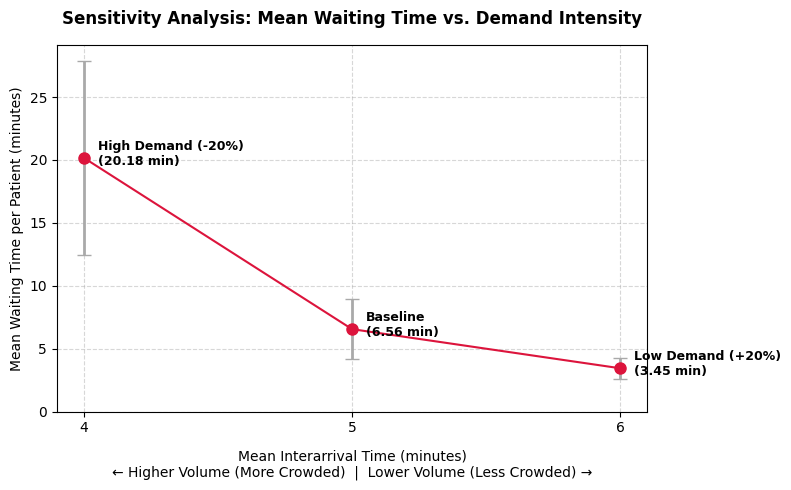

In [14]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set master seeds for 15 replications to maintain experimental control
np.random.seed(42)
arrival_seeds = np.random.randint(10000, 99999, size=15)
service_seeds = np.random.randint(10000, 99999, size=15)

def run_sensitivity_simulation(mean_interarrival, num_replications=15, env_duration=480):
    waiting_times_across_reps = []

    for rep in range(num_replications):
        # 1. Generate Patient Arrivals based on the current testing interval
        np.random.seed(arrival_seeds[rep])
        arrival_times = []
        current_time = 0
        while current_time < env_duration:
            interarrival = np.random.exponential(mean_interarrival)
            current_time += interarrival
            if current_time <= env_duration:
                arrival_times.append(current_time)

        if not arrival_times:
            waiting_times_across_reps.append(0.0)
            continue

        # 2. Generate Care Durations (Calibrated Triangular: 2.0, 3.5, 6.2)
        np.random.seed(service_seeds[rep])
        service_durations = [np.random.triangular(2.0, 3.5, 6.2) for _ in arrival_times]

        # 3. Core Single-Server Processing Loop
        server_free_at = 0.0
        waiting_times = []

        for arrival, duration in zip(arrival_times, service_durations):
            start_time = max(arrival, server_free_at)
            waiting_time = start_time - arrival
            waiting_times.append(waiting_time)
            server_free_at = start_time + duration

        waiting_times_across_reps.append(np.mean(waiting_times))

    return waiting_times_across_reps

# Define the Three Target Demand Levels (Mean Interarrival Times)
demand_scenarios = {
    "High Demand (-20%)": 4.0,
    "Baseline": 5.0,
    "Low Demand (+20%)": 6.0
}

sensitivity_results = {}

print("=== RUNNING SINGLE-SERVER SENSITIVITY ANALYSIS ===")
for label, interarrival_val in demand_scenarios.items():
    waits = run_sensitivity_simulation(interarrival_val)
    mean_wait = np.mean(waits)
    sem = stats.sem(waits)
    # Calculate 95% Confidence Interval boundaries (df = 14)
    ci_low, ci_high = stats.t.interval(0.95, len(waits) - 1, loc=mean_wait, scale=sem)

    sensitivity_results[interarrival_val] = {
        "label": label,
        "mean": mean_wait,
        "ci_err": ci_high - mean_wait, # Used for symmetric plotting error bars
        "ci_range": f"[{ci_low:.2f}, {ci_high:.2f}]"
    }
    print(f"{label} (Mean Interarrival: {interarrival_val} min) -> Mean Wait: {mean_wait:.2f} min | 95% CI: {sensitivity_results[interarrival_val]['ci_range']}")

# --- PLOTTING CODE ---
x_vals = sorted(list(sensitivity_results.keys())) # [4.0, 5.0, 6.0]
y_vals = [sensitivity_results[x]["mean"] for x in x_vals]
y_errs = [sensitivity_results[x]["ci_err"] for x in x_vals]

plt.figure(figsize=(8, 5))
plt.errorbar(x_vals, y_vals, yerr=y_errs, fmt='-o', color='crimson', ecolor='darkgray', elinewidth=2, capsize=5, markersize=8, label="Mean Wait time")

# Adding context labels to individual points
for x, y in zip(x_vals, y_vals):
    label_text = sensitivity_results[x]["label"]
    plt.annotate(f"{label_text}\n({y:.2f} min)", xy=(x, y), xytext=(10, -5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.title("Sensitivity Analysis: Mean Waiting Time vs. Demand Intensity", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Mean Interarrival Time (minutes)\n← Higher Volume (More Crowded)  |  Lower Volume (Less Crowded) →", fontsize=10, labelpad=10)
plt.ylabel("Mean Waiting Time per Patient (minutes)", fontsize=10)
plt.xticks(x_vals)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(bottom=0)
plt.tight_layout()

# Display plot frame
plt.show()
